A codificação de Huffman é basicamente transformar um simbolo em código, coisas que aparecem muito frequentemente ganham um código mais curto,
quanto mais raro é o texto, o código fica mais comprido. Como por exemplo na lingua portuguesa usa-se com mais frequencia a letra "A" do que o "Z", 
o "A" teria um código como "0", o Z é mais raro e teria um código mais complexo como "100101" (são apenas exemplos).
No final de tudo, a mensagem ficará muito mais pequena porque poupa-se imenso espaço nos caracteres mais comum.

C:\Users\tiago\AppData\Local\Temp\ipykernel_17892\3467871233.py:55: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  h, bins, patches = plt.hist(x, 256, [0, 256])


time:  0.0021016597747802734
Numero de simbolos na tabela:  256


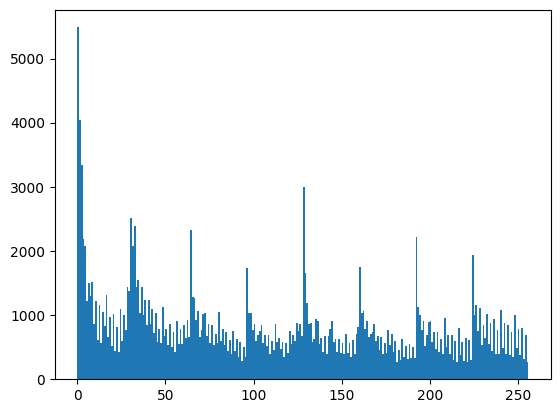

In [ ]:
from time import time
from os import path
import numpy as np
import cv2
import matplotlib.pyplot as plt

# define a função que vai gerar a tabela. ela recebe a lista de simbolos (numeros de 0 a 255) e as suas respetivas contagens ou probabilidades (prob_simbolos)
def gen_huff_table(simbolos, prob_simbolos):
    # 1. Criar a lista de nós inicial (apenas para símbolos com frequência > 0)
    # Cada nó é uma lista: [frequência, símbolo, esquerda, direita] 
    # Cria uma lista com todos os tons de cinza que realmente aparecem na imagem e cola-lhes a sua respetiva contagem (frequencia). Se um tom de cinza não
    # aparece nenhuma vez, é ignorado para não gastar espaço
    nodes = [] #cria uma lista vazia chamada nodes (nós). esta lista vai guardar temporariamente todos os pedaçoes da árvore enquanto consumimos.
    for i in range(len(simbolos)): 
        if prob_simbolos[i] > 0: #só avançamos se o símbolo apareceu pelo menos uma vez.
            nodes.append([prob_simbolos[i], simbolos[i], None, None]) #para cada simbolo válido, cria uma lista com 4 elementos e mete-a dentro de nodes:
            # 1. prob_simbolos[i]: a frequencia/probabilidade do simbolo
            # 2. simbolos[i]: o valor real do simbolo
            # 3. None: O filho da esquerda (que ainda não existe)
            # 4. None: O filho da direita (que ainda não existe)

    if len(nodes) == 0: return {} #se o ficheiro estiver vazio, a lista nodes estará vazia e a função retorna um dicionário vazio.
    if len(nodes) ==  1:
        return {nodes[0][1]: '0'} #se o ficheiro tiver um único simbolo repetido varias vezes, não dá para fazer uma árvore normal.
                                  # o codigo atribui-lhe imediatamente o bit "0".

    # 2. Construir a Árvore de Huffman
    # Isto funciona como um torneio de eliminação. O código ordena a lista para
    # encontrar os dois tons mais raros (que têm menor frequência), junta-os num "par"
    # (um nó pai) somando as suas frequências, e mete esse par de volta na lista. Isto repete-se
    # até restar apenas um nó gigante (a raiz da arvore).
    while len(nodes) > 1:
        nodes.sort(key=lambda x: x[0]) #ordena a lista nodes. O truque aqui é o key=lambda x: x[0], ordena com base no elemento
        # de indice 0 de cada nó (ou seja, a frequencia). Os dois nós com menor frequencia vão ficar sempre logo no inicio da lista.

        # Extrair os dois nós com menores frequências
        esquerda = nodes.pop(0) # o método pop(0) remove e devolve o primeiro elemento da lista (o mais pequeno de todos).
        direita = nodes.pop(0) # como foi removido o primeiro, o segundo elemento mais pequeno passou a ser o novo primeiro. removemos tambem.

        # Criar nó pai (soma das frequências, símbolo None, filhos esquerda e direita)  
        novo_no = [esquerda[0] + direita[0], None, esquerda, direita] #criamos um nó pai para juntar esses dois a estrutura dele segue a mesma logica.
        nodes.append(novo_no)   

    # 3. Gerar os códigos binários percorrendo a árvore (Recursividade)
    tabela_huffman = {}
    raiz = nodes[0]
    stack = [[raiz, ""]] # Guarda [nó, código_acumulado]
    #cria uma lista chamada stack. criamos a raiz da arvore (ponto de partida) e uma string vazia que vai acumular os bits do codigo

    # Agora que temos uma árvore gigante, partimos do topo (raiz) e vamos 
    # descendo até chegar a cada tom de cinza individual.
    # A regra é simples: cada vez que se vai para a esquerda, adiciona-se um 0 ao código.
    # Cada vez que vai-se para a direita, adiciona-se um 1.
    # Chegando ao fim da linha (um simbolo real), guarda-se esse caminho da tabela_huffman
    while len(stack) > 0:
        no, codigo = stack.pop() #retira o ultimo elemento que foi colocado no stack para analisar agora. "no" recebe a estrutura 
                                 #do nó e "codigo" recebe a string de bits acumulada até ali.

        # Se tem símbolo, é folha
        if no[1] is not None:
            tabela_huffman[no[1]] = codigo #como chegámos ao fim, guardamos no nosso dicionário o simbolo (no[1]) associado ao codigo de bits
                                           #que acumulámos para chegar até ele.
        else: #se o indice 1 for None, significa que estamos num nó intermédio (pai) e temos de continuar a descer para os filhos
            #Adiciona filhos à stack (Direita = 1, Esquerda = 0)
            if no[3] is not None:
                stack.append([no[3], codigo + "1"]) #verifica se existe um filho na direita (no[3]). se existir, coloca-o na pilha
                                                    #para ser explorado mais tarde, e adiciona o bit "1" ao código acumulado.
            if no[2] is not None:
                stack.append([no[2], codigo + "0"]) #verifica se existe um filho na esquerda (no[2]). se existir, coloca-o na pilha 
                                                    #e adiciona o bit "0" ao codigo acumulado.   
    return tabela_huffman                      


# Ler um dos ficheiros
x = np.fromfile("LenaGray.tif", dtype ="uint8")

# Calcular o histogram
h, bins, patches = plt.hist(x, 256, [0, 256])

# Gerar o codigo de Huffman
to = time()

# O que a função faz é mais ou menos isto: O pixel 128 (muito comum) vira 01 (apenas 2 bits),
# o pixel 255 (muito raro) vira 11101011 (8 bits)
tabela_codigo = gen_huff_table(np.arange(0, 256), h)
t1 = time()

print("time: ", t1 - to)
print("Numero de simbolos na tabela: ", len(tabela_codigo))


In [ ]:
# simbolos -> o teu ficheiro original lido como um array de bytes (a variavel x, que contém todos os pixeis da Lena em sequencia).
# tabela -> o dicionário de tradução que gerámos antes (a tabela_codigo), que diz que o pixel X corresponde aos bits Y.

def encode_huff(simbolos, tabela):
    mensagem_codificada = [tabela[s] for s in simbolos] # para cada simbolo s presente na lista de simbolos originais, vai à tabela 
                                                        # buscar o seu código binário correspondente.

    return "".join(mensagem_codificada) # o método "".join() junta (concatena) todos os elementos de uma lista de textos numa única string,
                                        # sem espaços ou seperadores entre eles.

# Codificar a mensagem
seq_bit0 = encode_huff(x, tabela_codigo)

In [ ]:
# define a função que recebe a string de bits comprimida (sequencia_bits) e o dicionário de tradução (tabela).

def decode_huff(sequencia_bits, tabela):
    root  = {} # cria um dicionario vazio chaamdo root (raiz). será a base do mapa/árvore
    for simbolo, codigo in tabela.items(): #corre todas as linhas da tabela. em cadad volta do ciclo, o simbolo 
                                           #recebe o tom de cinza e o código recebe os bits.
        node = root #antes de começar a ler os bits do codigo, colocamos o nosso ponteiro(node) no topo do mapa(root)
        for bit in codigo:
            if bit not in node:
                node[bit] = {} #se o caminho para este bit (seja '0' ou '1') ainda não existir na nossa caixa atual,
                               #criamos uma nova caixa vazia {} lá dentro. isto é cirar um ramo da árvore na memória.
            node = node[bit] #entramos dentro dessa nova caixa (avançamos um passo na árvore). o node atualiza-se para a caixa
                             #onde acabámos de entrar.
        node['res'] = simbolo #quando o ciclo "for bit in codigo" termina, significa que chegámos à ponta do ramo (à folha). Criamos uma etiqueta
                              #especial chamada 'res' (resultado) e guardamos lá o valor do simbolo real (o tom de cinza). 

    simbolos_descodificados = [] #cria uma lsita vazia para ir guardando os pixeis que foram recuperando.
    node = root #voltamos a colocar o nosso ponteiro no topo do mapa (root) para começar a ler a mensagem do inicio.
    for bit in sequencia_bits: #inicia o ciclo que vai ler cada bit da string comprimida da Lena('0's e '1's) um por um.
        if bit not in node:
            break #uma proteção especial contra o padding (aqueles zeros extra que o packbits mete no fim do ficheiro para completar
                  # o ultimo byte). Se o bit que estamos a ler não existir no mapa naquela posição da árvore, o programa sabe que a 
                  # a mensagem real acabou e faz um break.
        node = node[bit] #caminha na árvore. se o bit lido for '0', entramos na ramificação do '0'. se for '1' entramos na do '1'.
        if 'res' in node: #verifica se a caixa onde acabámos de entrar tem a tal etiquet aespecial 'res'. se tiver, significa que 
                          #encontrámos o fim de um código válido.
            simbolos_descodificados.append(node['res']) #retira o simbolo guardado nessa etiqueta (o pixel original) e adiciona-o à 
                                                        # lista de resultados
            node = root #como encontrámos um simbolo, o ponteiro volta para o topo da árvore para começar a decifrar o proximo pixel.

    return np.array(simbolos_descodificados, dtype="uint8")                          

In [ ]:
def encode_table(tabela):
    bits_tabela = "" #inicializa uma string vazia chamada bits_tabela que vai acumular todos os bits do cabeçalho.
    num_entradas = len(tabela)

    val_to_bin = 0 if num_entradas == 256 else num_entradas #o numero maximo de simbolos é 256. mas o maior numero que conseguimos escrever com 8 bits
                                                            #é 255. Para não gastarmos 9 bits só com este contador. criamos a convenção: se a tabela tiver
                                                            #256 simbolos, guardamos o valor 0. o descodificador saberá que se ler um 0, na verdade significa 256.
    bits_tabela += bin(val_to_bin)[2:].zfill(8) #transforma o numero de entradas em binário com exatamente 8 bits. 
                                                #bin(val_to_bin): converte o numero. (ex: 5 vira '0b101')
                                                #[2:]: Corta o '0b' inicial do texto, sobrando apenas '101'.
                                                #zfill(8): Preenche com zeros à esquerda até prefazer 8 caracteres (ex: '101' vira '00000101')
    for simbolo, codigo in tabela.items(): 
        bits_simbolo = bin(int(simbolo))[2:].zfill(8) #pega no valor do simbolo (0 a 255) e converte-o para uma string binária de 8 bits.
        bits_size = bin(len(codigo))[2:].zfill(8) #mede quantos bits tem o código de Huffman deste simbolo e guarda esse tamanho numa string binária de 8 bits.
        bits_tabela += bits_simbolo + bits_size + codigo #junta tudo na string principal: os 8 bits do tamanho + os bits do código em si.
    return bits_tabela    

# Codificar a tabela
seq_bit_tabela = encode_table(tabela_codigo) #executa a função para gerar o cabeçalho em bits
seq_bit_total = seq_bit_tabela + seq_bit0 #junta tudo num bloco só. coloca os bits da tabela à cabeça
                                          #e, logo a seguir, os bits da imagem comprimida (seq_bit0).

print("Tamanho da tabela (bits):", len(seq_bit_tabela))
print("Tamanho total (tabela + mensagem):", len(seq_bit_total))

Tamanho da tabela (bits): 6212
Tamanho total (tabela + mensagem): 1643322


In [ ]:
#define a função que recebe a string com todos os bits juntos na variavel seq_bits, e o nome que queres dar ao ficheiro final.

def write2file(seq_bits, nome_ficheiro):
    padding = (8 - len(seq_bits) % 8) % 8 #calcula o padding (enchimento). como os computadores só gravam multiplos exatos de 8 bits (1 byte), 
                                          #se a tua sequencia total tiver, por exemplo, 83 bits, vão faltar 5 bits para completar o ultimo byte
                                          #(88-83=5).
                                          #len(seq_bits) % 8 dá o resto da divisão por 8 (quantos bits "sobraram" no ultimo byte incompleto).
                                          #8-resto diz quantos bits faltam para chegar a 8.
                                          #o "%8" no final é uma proteção: se a sequencia já for um multiplo perfeito de 8, faltam 0 bits.
    seq_bits_ajustada = seq_bits + ("0" * padding) #ajusta a sequencia de bits adicionando os zeros que calculámos em falta no final da string.

    bit_array = np.array([int(b) for b in seq_bits_ajustada], dtype=np.uint8) #transforma a string de texto (ex:"0101") num array real do numpy
                                                                              #onde cada número é um inteiro de 8 bits

    byte_array = np.packbits(bit_array) #o metodo np.packbits pega no array de numeros 0 e 1 e junta-os de 8 em 8, comprimindo em bytes reais.

    with open(nome_ficheiro, "wb") as f: #abre (ou cria) o ficheiro no disco com o nome escolhido. o modo "wb"
                                         #signfica Write Binary. É obrigatorio usar este modo porque não estamos a gravar texto simples, mas sim dados
                                         #binários puros (bytes).
        f.write(byte_array.tobytes()) #converte o array do numpy em bytes puros da linguagem python (.tobytes()) e descarrega-os diretamento para dentro
                                      #do ficheiro no disco rígido.

    print(f"Ficheiro '{nome_ficheiro}' gravado com sucesso")
    print(f"Tamanho final no disco: {len(byte_array)} bytes.")        

In [ ]:
#recebe seq_total, que é a string com todos os bits lidos do ficheiro.

def decode_table(seq_total):
    num_entrada = int(seq_total[:8], 2) #lê os primeiros 8 bits da string e converte-os de binário para um numero inteiro comum do python. isto diz
                                        #quantos simbolos existem guardados nesta tabela.
    if num_entrada == 0: num_entrada = 256 #desfaz o truque de poupança no espaço onde foi feita a gravação. se os pirmeiros 8 bits diziam 0, o programa
                                           #sabe que, na verdade, a tabela está completa e tem 256 entradas.

    pos = 8 #cria uma variável chamada pos(posição). Como já foram lidos os primeiros 8 bits, avança para a posição 8, pronto para começar a ler o primeiro simbolo.
    tabela_recuperada = {} #cria um dicionário vazio, onde vamos reconstruir a tabela de Huffman à medida que se vai decifrando.
    for _ in range(num_entrada): #inicia o ciclo que vai extrar as linhas da tabela uma a uma
        simbolo = int(seq_total[pos:pos+8], 2)
        pos += 8 #lê o bloco de 8 bits a partir de onde a posição está. Converte esses 8 bits para um numero inteiro (que será o valor original do pixel, de 0 a 255).
                 #Logo a seguir, move a posição 8 posições para a frente.
        tamanho_codigo = int(seq_total[pos:pos+8], 2)
        pos+=8 #lê os primeiros 8 bits para descobrir o tamanho do código de Huffman desse símbolo. Converte para inteiro e avança o dedo mais 8 posições.
        codigo = seq_total[pos:pos+tamanho_codigo]
        pos+=tamanho_codigo #agora que já se sabe o tamanho, o programa recorta exatamente essa quantidade de caracteres a partir da posição atual. isto extrai
                            #a string de bits correspondente ao código de Huffman (ex:"010"). Depois, atualiza a posição avançando o tamanho do código que acabou de ler.
        tabela_recuperada[simbolo] = codigo #guarda o par no novo dicionario
    return tabela_recuperada, seq_total[pos:] #devolve a tabela reconstruida e o resto da string de bits a partir da posição onde parou.

In [ ]:
def read_file(nome_ficheiro):
    with open(nome_ficheiro, "rb") as f:
        conteudo_bytes = f.read() #abre o ficheiro em modo "rb" (Read Binary). Este modo é obrigatório porque os dados lá dentro são bytes puros e não
                                  #texto legível. O método f.read() suga o conteúdo todo do ficheiro de uma só vez e guarda-o na variável conteudo_bytes.

    bit_array = np.unpackbits(np.frombuffer(conteudo_bytes,  dtype=np.uint8)) #o contrário de np.packbits(), pega nos bytes e garante que o python interpreta
                                                                              #como um array de numeros inteiros de 8 bits (valores de 0 a 255).
    seq_total = "".join(bit_array.astype(str)) #transforma o array de numeros puros (0 e 1) de volta numa string de texto contendo apenas os caracteres '0' e '1'.
                                               #.astype(str): converte temporariamente os numeros 0 e 1 nos caracteres de texto '0' e '1'.
                                               #"".join(...): cola todos esses caracteres uns aos outros, sem espaços.

    tabela_recuperada, bits_mensagem = decode_table(seq_total) #envia a string seq_total para a função decode_table. Essa função vai ler o inicio da string,
                                                               #reconstruir o dicionario da tabela de huffman e devolver:
                                                               #a tabela reconstruída e o resto dos bits que sobram, ou seja, os bits da imagem comprimida.

    return tabela_recuperada, bits_mensagem    

In [ ]:
#define a função que recebe o histograma h (contagens de cada pixel) e a tabela_codigo (o dicionario de Huffman)

def calcular_estatisticas(h, tabela_codigo):
    prob = h[h > 0]/ np.sum(h) #calcula a probabilidade de cadad simbolo que realmente existe no ficheiro.
                               #np.sum(h) dá o numero total de pixeis na imagem.
                               #h[h>0] filtra o histograma para ignorar os tons de cinza que nunca apareceram (frequencia 0).
                               #Isto é necessário porque o logaritmo de zero não existe na matemática.

    entropia = -np.sum(prob * np.log2(prob)) #Aplica a fórmula de Shannon para a entropia. A entropia mede o "grau de surpresa"
                                             #ou a quantidade de informação pura contida na fonte. Ela diz-te, de forma rígida, qual é o limite mínimo
                                             #absoluto de bits por simbolo que precisas para guardar aquele ficheiro sem perder informação.
                                             #Se a entropia der 7.44, é matematicamente impossível fazer uma compressão lossless(sem perdas) que gaste
                                             #menos de 7.44 bits por pixel.

    comp_medio = 0 #cria uma variável acumuladora para calcular o comprimento medio das palavras de codigo (L).
    for simbolo, codigo in tabela_codigo.items():
        p_i = h[simbolo]/ np.sum(h) #calcula a probabilidade do simbolo atual (a contagem dele a dividir pelo total de pixeis)
        comp_medio += p_i * len(codigo) #aplica a formula teorica do comprimento. L = L=∑p * li, onde li é o tamanho do código binario.

    eficiencia = (entropia / comp_medio) * 100 #calcula a eficiencia percentual do codigo de huffman. indica o quão perto o código real ficou do limite
                                               #perfeito da entropia.
    return entropia, comp_medio, eficiencia    

In [ ]:
lista_ficheiros = ["LenaGray.tif", "LenaColor.tif", "DecUniversalDH.txt", "HenryMancini-PinkPanther30s.mp3"]

for nome_f in lista_ficheiros:
    if not path.exists(nome_f):
        print(f"\nFicheiro {nome_f} não encontrado. Próximo...")
        continue
    
    print(f"\n---Analisando: {nome_f} ---")

    dados_originais = np.fromfile(nome_f, dtype="uint8") 

    # a) gerar tabela e medir tempo
    h, _ = np.histogram(dados_originais, bins=256, range=(0, 256))
    t0 = time()
    tabela = gen_huff_table(np.arange(256), h)
    t1 = time()
    print(f"Tempo Geração Tabela: {t1 - t0:.6f}s")

    #primeiro faz-se a contagem com o np.histogram. uso o par t0 = time() e t1 = time() para capturar o relógio do computador antes e depois de chamar a função
    #gen_huff_table. Ao subtrair t1-t0, descubro e imprimo quantos segundos demorou a cair a árvore.

    # b) estatisticas
    Entropia, Comprimento, Eficiencia = calcular_estatisticas(h, tabela)
    print(f"Entropia:  {Entropia:.4f} bits/simbolo")
    print(f"Nº médio de bits (Comprimento): {Comprimento:.4f} bits/simbolo")
    print(f"Eficiência: {Eficiencia:.2f}%")

    #envia o histograma e a tabela gerada para a função estatística. devolve os três valores que imprimo logo a seguir com o formato :.4f (apenas 4 casas decimais).

    # c) codificar mensagem
    t_enc_0 = time()
    seq_bits_msg = encode_huff(dados_originais, tabela)
    t_enc_1 = time()
    print(f"Tempo Codificação: {t_enc_1 - t_enc_0:.6f}s")

    #executa a tradução dos pixeis/caracteres para a string de bits usando a encode_huff. Mede e imprime também o tempo que a compressão demorou.

    # d) Gravar Ficheiro
    seq_bits_tab = encode_table(tabela)
    stream_total = seq_bits_tab + seq_bits_msg
    nome_comp = nome_f + ".huff"
    write2file(stream_total, nome_comp)

    #gera o cabeçalho binário da tabela (seq_bits_tab), junta-o à mensagem comprimida criando a stream_total, define o novo nome do ficheiro adicionando a 
    #extensão .huff e envia tudo para a write2file para prensar os bits e gravá-los fisicamente no teu disco.

    size_ini = path.getsize(nome_f)
    size_end = path.getsize(nome_comp)
    print(f"Taxa de Compressão: {size_ini / size_end:.2f}:1")

    #mede a eficácia real de espaço no disco rígido. o path.getsize vai buscar o tamanho em bytes do ficheiro original e do ficheiro .huff comprimido. 
    #ao dividir um pelo outro, calcula a taxa de compressão. 

    # e) e f) ler e descodificar
    t_dec_0 = time()
    tab_lida, msg_lida = read_file(nome_comp)
    dados_recuperados  = decode_huff(msg_lida, tab_lida)
    dados_recuperados = dados_recuperados[:len(dados_originais)]
    t_dec_1 = time()
    print(f"Tempo de Descodificação: {t_dec_1 - t_dec_0:.6f}s")

    #faz o teste ao descodificador. abre o ficheiro .huff que foi gravado no disco, separa a tabela da mensagem (read_file) e reconstrói 
    #o array de bytes original usando a função decode_huff.
    #a linha dados_recuperados = dados_recuperados[:len(dados_originais)] deita fora os bits de padding (zeros extra) que possam ter sido
    #adicionados no fim do ficheiro pelo packbits, garantindo que o array reconstruído tem exatamente o mesmo tamanho do original. mede e
    #imprime o tempo total desta operação.

    # g) Verificação de Erro  Nulo
    igual = np.array_equal(dados_originais, dados_recuperados)
    print(f"Recuperação Perfeita (Erro Nulo): {igual}")
    
    #o método np.array_equal compara os dois arrays elemento e elemento, na mesma posição. ele só devolve True se todos os bytes forem rigorosamente
    #identicos. se der True, prova-se com sucesso absoluto que o compressor funciona e é lossless (sem perdas).


---Analisando: LenaGray.tif ---
Tempo Geração Tabela: 0.003145s
Entropia:  7.7614 bits/simbolo
Nº médio de bits (Comprimento): 7.7912 bits/simbolo
Eficiência: 99.62%
Tempo Codificação: 0.020844s
Ficheiro 'LenaGray.tif.huff' gravado com sucesso
Tamanho final no disco: 205416 bytes.
Taxa de Compressão: 1.02:1
Tempo de Descodificação: 0.555625s
Recuperação Perfeita (Erro Nulo): True

---Analisando: LenaColor.tif ---
Tempo Geração Tabela: 0.002007s
Entropia:  7.7514 bits/simbolo
Nº médio de bits (Comprimento): 7.7818 bits/simbolo
Eficiência: 99.61%
Tempo Codificação: 0.074158s
Ficheiro 'LenaColor.tif.huff' gravado com sucesso
Tamanho final no disco: 765903 bytes.
Taxa de Compressão: 1.03:1
Tempo de Descodificação: 2.192908s
Recuperação Perfeita (Erro Nulo): True

---Analisando: DecUniversalDH.txt ---
Tempo Geração Tabela: 0.000000s
Entropia:  4.4170 bits/simbolo
Nº médio de bits (Comprimento): 4.4519 bits/simbolo
Eficiência: 99.22%
Tempo Codificação: 0.001003s
Ficheiro 'DecUniversalDH.txt